In [3]:
import pandas as pd
import sqlite3
from sklearn.impute import KNNImputer
from sklearn.impute import SimpleImputer
from scipy.stats.mstats import winsorize
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
import seaborn as sns

# Load CSV
riders = pd.read_csv("riders_data.csv")
print(riders)

    rider_id           name  age  gender       city signup_date  total_rides  \
0      R0001      Aarav Das   23    Male       Pune  2020-06-29           56   
1      R0002    Ishaan Nair   39  Female     Mumbai  2019-11-23           70   
2      R0003    Kavya Reddy   34    Male       Pune  2023-05-04           45   
3      R0004     Aarav Nair   19   Other    Kolkata  2019-07-28          464   
4      R0005     Diya Reddy   27    Male  Ahmedabad  2021-05-31          294   
..       ...            ...  ...     ...        ...         ...          ...   
295    R0296  Reyansh Patel   37   Other  Hyderabad  2021-02-20          390   
296    R0297   Saanvi Gupta   47    Male       Pune  2023-09-20          396   
297    R0298   Vivaan Singh   35  Female  Ahmedabad  2020-03-25           65   
298    R0299   Ishaan Gupta   33   Other    Kolkata  2020-09-04          457   
299    R0300    Saanvi Iyer   38  Female    Kolkata  2023-07-08          291   

     cancelled_rides  avg_rating  
0   

In [5]:
# Load JSON
trips = pd.read_json("trips.json")
print(trips)

     trip_id rider_id     zone  distance_km  duration_min  fare_amount  \
0     T00001    R0037  Zone_10        11.83         74.59       104.88   
1     T00002    R0104   Zone_9         3.86         35.59        40.48   
2     T00003    R0045   Zone_8         4.70         31.03        46.39   
3     T00004    R0089   Zone_2        11.06         59.48       257.64   
4     T00005    R0003   Zone_5         7.28         67.59        72.74   
...      ...      ...      ...          ...           ...          ...   
1995  T01996    R0171   Zone_6         0.91          6.44        22.12   
1996  T01997    R0287   Zone_5        11.40        103.03       193.75   
1997  T01998    R0254   Zone_9         4.94         39.32        58.45   
1998  T01999    R0267   Zone_2         7.76         51.43        74.92   
1999  T02000    R0202  Zone_10        12.02        114.45       149.05   

     payment_mode   ride_date  surge_flag  
0            Cash  2023-11-13           0  
1            Cash  2023

In [6]:
import sqlite3

conn = sqlite3.connect("")

print("Connected Successfully")

conn.close()

Connected Successfully


In [7]:
# Load SQL
conn = sqlite3.connect("city_zones.db")
with open("city_zones.sql", "r") as f:
    conn.executescript(f.read())

zones = pd.read_sql("SELECT * FROM city_zones", conn)
print(zones)

  zone_name  population_density  traffic_index  avg_speed_kmph    zone_type
0    Zone_1                4921           2.43            30.9  Residential
1    Zone_2                6371           0.91            58.4  Residential
2    Zone_3               12971           2.11            38.0     Business
3    Zone_4                4038           2.46            48.2     Business
4    Zone_5                2590           1.31            43.9     Business
5    Zone_6               14627           0.54            37.6        Mixed
6    Zone_7               11070           0.64            45.2   Industrial
7    Zone_8                4516           1.93            31.0     Business
8    Zone_9               11037           1.83            56.1        Mixed
9   Zone_10                2440           1.54            35.4   Industrial


In [47]:

print(riders.head())
print(trips.head())
print(zones.head())

  rider_id         name  age  gender       city signup_date  total_rides  \
0    R0001    Aarav Das   23    Male       Pune  2020-06-29           56   
1    R0002  Ishaan Nair   39  Female     Mumbai  2019-11-23           70   
2    R0003  Kavya Reddy   34    Male       Pune  2023-05-04           45   
3    R0004   Aarav Nair   19   Other    Kolkata  2019-07-28          464   
4    R0005   Diya Reddy   27    Male  Ahmedabad  2021-05-31          294   

   cancelled_rides  avg_rating  
0                0        3.76  
1                5        4.12  
2                9        3.76  
3                5        3.19  
4               30        3.53  
  trip_id rider_id     zone  distance_km  duration_min  fare_amount  \
0  T00001    R0037  Zone_10        11.83         74.59       104.88   
1  T00002    R0104   Zone_9         3.86         35.59        40.48   
2  T00003    R0045   Zone_8         4.70         31.03        46.39   
3  T00004    R0089   Zone_2        11.06         59.48       

In [30]:
print(riders.info())
print(trips.info())
print(zones.info())

<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   rider_id         300 non-null    str    
 1   name             300 non-null    str    
 2   age              300 non-null    int64  
 3   gender           300 non-null    str    
 4   city             300 non-null    str    
 5   signup_date      300 non-null    str    
 6   total_rides      300 non-null    int64  
 7   cancelled_rides  300 non-null    int64  
 8   avg_rating       300 non-null    float64
dtypes: float64(1), int64(3), str(5)
memory usage: 21.2 KB
None
<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   trip_id       2000 non-null   str    
 1   rider_id      2000 non-null   str    
 2   zone          2000 non-null   str    
 3   distance_km   2000 non

In [48]:
print(riders.isnull().sum())
print(trips.isnull().sum())
print(zones.isnull().sum())

rider_id           0
name               0
age                0
gender             0
city               0
signup_date        0
total_rides        0
cancelled_rides    0
avg_rating         0
dtype: int64
trip_id         0
rider_id        0
zone            0
distance_km     0
duration_min    0
fare_amount     0
payment_mode    0
ride_date       0
surge_flag      0
dtype: int64
zone_name             0
population_density    0
traffic_index         0
avg_speed_kmph        0
zone_type             0
dtype: int64


In [49]:
print("Riders duplicates =", riders.duplicated().sum())
print("Trips duplicates =", trips.duplicated().sum())
print("Zones duplicates =", zones.duplicated().sum())

Riders duplicates = 0
Trips duplicates = 0
Zones duplicates = 0


In [50]:
# 2.Data cleaning
#numeric missing values

num_cols = riders.select_dtypes(include='number').columns

imputer = SimpleImputer(strategy='mean')

riders[num_cols] = imputer.fit_transform(riders[num_cols])
print(riders)

    rider_id           name   age  gender       city signup_date  total_rides  \
0      R0001      Aarav Das  23.0    Male       Pune  2020-06-29         56.0   
1      R0002    Ishaan Nair  39.0  Female     Mumbai  2019-11-23         70.0   
2      R0003    Kavya Reddy  34.0    Male       Pune  2023-05-04         45.0   
3      R0004     Aarav Nair  19.0   Other    Kolkata  2019-07-28        464.0   
4      R0005     Diya Reddy  27.0    Male  Ahmedabad  2021-05-31        294.0   
..       ...            ...   ...     ...        ...         ...          ...   
295    R0296  Reyansh Patel  37.0   Other  Hyderabad  2021-02-20        390.0   
296    R0297   Saanvi Gupta  47.0    Male       Pune  2023-09-20        396.0   
297    R0298   Vivaan Singh  35.0  Female  Ahmedabad  2020-03-25         65.0   
298    R0299   Ishaan Gupta  33.0   Other    Kolkata  2020-09-04        457.0   
299    R0300    Saanvi Iyer  38.0  Female    Kolkata  2023-07-08        291.0   

     cancelled_rides  avg_r

In [10]:
#categorical missing value using most fre strategy
cat_cols = riders.select_dtypes(include='object').columns

cat_imputer = SimpleImputer(strategy='most_frequent')

riders[cat_cols] = cat_imputer.fit_transform(riders[cat_cols])

print(riders)

    rider_id           name  age  gender       city signup_date  total_rides  \
0      R0001      Aarav Das   23    Male       Pune  2020-06-29           56   
1      R0002    Ishaan Nair   39  Female     Mumbai  2019-11-23           70   
2      R0003    Kavya Reddy   34    Male       Pune  2023-05-04           45   
3      R0004     Aarav Nair   19   Other    Kolkata  2019-07-28          464   
4      R0005     Diya Reddy   27    Male  Ahmedabad  2021-05-31          294   
..       ...            ...  ...     ...        ...         ...          ...   
295    R0296  Reyansh Patel   37   Other  Hyderabad  2021-02-20          390   
296    R0297   Saanvi Gupta   47    Male       Pune  2023-09-20          396   
297    R0298   Vivaan Singh   35  Female  Ahmedabad  2020-03-25           65   
298    R0299   Ishaan Gupta   33   Other    Kolkata  2020-09-04          457   
299    R0300    Saanvi Iyer   38  Female    Kolkata  2023-07-08          291   

     cancelled_rides  avg_rating  
0   

C:\Users\admin\AppData\Local\Temp\ipykernel_4524\3191462461.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = riders.select_dtypes(include='object').columns


In [52]:
#KNN IMPUTER

knn = KNNImputer(n_neighbors=5)

cols = ['duration_min','distance_km','fare_amount']

trips[cols] = knn.fit_transform(trips[cols])
print(trips)

     trip_id rider_id     zone  distance_km  duration_min  fare_amount  \
0     T00001    R0037  Zone_10        11.83         74.59       104.88   
1     T00002    R0104   Zone_9         3.86         35.59        40.48   
2     T00003    R0045   Zone_8         4.70         31.03        46.39   
3     T00004    R0089   Zone_2        11.06         59.48       257.64   
4     T00005    R0003   Zone_5         7.28         67.59        72.74   
...      ...      ...      ...          ...           ...          ...   
1995  T01996    R0171   Zone_6         0.91          6.44        22.12   
1996  T01997    R0287   Zone_5        11.40        103.03       193.75   
1997  T01998    R0254   Zone_9         4.94         39.32        58.45   
1998  T01999    R0267   Zone_2         7.76         51.43        74.92   
1999  T02000    R0202  Zone_10        12.02        114.45       149.05   

     payment_mode   ride_date  surge_flag  
0            Cash  2023-11-13           0  
1            Cash  2023

In [53]:
#Convert Date Format
trips['ride_date'] = pd.to_datetime(trips['ride_date'])
print(trips)

     trip_id rider_id     zone  distance_km  duration_min  fare_amount  \
0     T00001    R0037  Zone_10        11.83         74.59       104.88   
1     T00002    R0104   Zone_9         3.86         35.59        40.48   
2     T00003    R0045   Zone_8         4.70         31.03        46.39   
3     T00004    R0089   Zone_2        11.06         59.48       257.64   
4     T00005    R0003   Zone_5         7.28         67.59        72.74   
...      ...      ...      ...          ...           ...          ...   
1995  T01996    R0171   Zone_6         0.91          6.44        22.12   
1996  T01997    R0287   Zone_5        11.40        103.03       193.75   
1997  T01998    R0254   Zone_9         4.94         39.32        58.45   
1998  T01999    R0267   Zone_2         7.76         51.43        74.92   
1999  T02000    R0202  Zone_10        12.02        114.45       149.05   

     payment_mode  ride_date  surge_flag  
0            Cash 2023-11-13           0  
1            Cash 2023-07

In [54]:
#Remove Unrealistic Entries
#Negative Fare
trips = trips[trips['fare_amount'] >= 0]
print(trips)

     trip_id rider_id     zone  distance_km  duration_min  fare_amount  \
0     T00001    R0037  Zone_10        11.83         74.59       104.88   
1     T00002    R0104   Zone_9         3.86         35.59        40.48   
2     T00003    R0045   Zone_8         4.70         31.03        46.39   
3     T00004    R0089   Zone_2        11.06         59.48       257.64   
4     T00005    R0003   Zone_5         7.28         67.59        72.74   
...      ...      ...      ...          ...           ...          ...   
1995  T01996    R0171   Zone_6         0.91          6.44        22.12   
1996  T01997    R0287   Zone_5        11.40        103.03       193.75   
1997  T01998    R0254   Zone_9         4.94         39.32        58.45   
1998  T01999    R0267   Zone_2         7.76         51.43        74.92   
1999  T02000    R0202  Zone_10        12.02        114.45       149.05   

     payment_mode  ride_date  surge_flag  
0            Cash 2023-11-13           0  
1            Cash 2023-07

In [55]:
#Zero Distance but Fare Charged
trips = trips[~((trips['distance_km']==0) & (trips['fare_amount']>0))]
print(trips)

     trip_id rider_id     zone  distance_km  duration_min  fare_amount  \
0     T00001    R0037  Zone_10        11.83         74.59       104.88   
1     T00002    R0104   Zone_9         3.86         35.59        40.48   
2     T00003    R0045   Zone_8         4.70         31.03        46.39   
3     T00004    R0089   Zone_2        11.06         59.48       257.64   
4     T00005    R0003   Zone_5         7.28         67.59        72.74   
...      ...      ...      ...          ...           ...          ...   
1995  T01996    R0171   Zone_6         0.91          6.44        22.12   
1996  T01997    R0287   Zone_5        11.40        103.03       193.75   
1997  T01998    R0254   Zone_9         4.94         39.32        58.45   
1998  T01999    R0267   Zone_2         7.76         51.43        74.92   
1999  T02000    R0202  Zone_10        12.02        114.45       149.05   

     payment_mode  ride_date  surge_flag  
0            Cash 2023-11-13           0  
1            Cash 2023-07

In [56]:
#3. Outlier Handling
#Z-Score (Fare & Distance)
from scipy.stats import zscore

trips['fare_z'] = zscore(trips['fare_amount'])
trips['distance_z'] = zscore(trips['distance_km'])

outliers = trips[(abs(trips['fare_z'])>3) | (abs(trips['distance_z'])>3)]

print(outliers)

     trip_id rider_id     zone  distance_km  duration_min  fare_amount  \
66    T00067    R0032   Zone_6        16.72        100.34       394.44   
306   T00307    R0090   Zone_4        17.80        146.74       435.50   
431   T00432    R0075   Zone_6        25.86        178.53       344.97   
550   T00551    R0121   Zone_9        21.83        190.53       354.27   
754   T00755    R0029   Zone_8        17.84        165.01       404.34   
817   T00818    R0095   Zone_8        20.20        152.79       465.18   
1095  T01096    R0070   Zone_8        19.36        144.13       443.64   
1176  T01177    R0253   Zone_6        17.18        169.04       410.94   
1357  T01358    R0118   Zone_4        22.25        183.60       317.32   
1421  T01422    R0237   Zone_5        18.14         94.02       391.32   
1542  T01543    R0175   Zone_6        16.11        146.94       394.11   
1617  T01618    R0212   Zone_8        19.08        127.16       432.46   
1694  T01695    R0028   Zone_6        

In [57]:
#IQR Method (Duration)
Q1 = trips['duration_min'].quantile(0.25)
Q3 = trips['duration_min'].quantile(0.75)

IQR = Q3-Q1

lower = Q1-1.5*IQR
upper = Q3+1.5*IQR

duration_outliers = trips[(trips['duration_min']<lower) |
                          (trips['duration_min']>upper)]

print(duration_outliers)

     trip_id rider_id     zone  distance_km  duration_min  fare_amount  \
57    T00058    R0020  Zone_10        18.28        161.83       161.65   
185   T00186    R0222   Zone_6        17.92        173.85       213.11   
290   T00291    R0169  Zone_10        20.80        164.64       379.11   
343   T00344    R0036   Zone_8        17.02        161.82       174.34   
425   T00426    R0177   Zone_9        17.24        167.72       310.76   
431   T00432    R0075   Zone_6        25.86        178.53       344.97   
550   T00551    R0121   Zone_9        21.83        190.53       354.27   
754   T00755    R0029   Zone_8        17.84        165.01       404.34   
1064  T01065    R0092   Zone_4        19.07        184.53       374.64   
1168  T01169    R0241   Zone_5        16.13        160.35       197.92   
1176  T01177    R0253   Zone_6        17.18        169.04       410.94   
1348  T01349    R0023   Zone_7        17.16        162.72       261.85   
1357  T01358    R0118   Zone_4        

In [58]:
#Winsorization

trips['fare_amount'] = winsorize(trips['fare_amount'],
                                 limits=[0.01,0.01])
print(trips)

     trip_id rider_id     zone  distance_km  duration_min  fare_amount  \
0     T00001    R0037  Zone_10        11.83         74.59       104.88   
1     T00002    R0104   Zone_9         3.86         35.59        40.48   
2     T00003    R0045   Zone_8         4.70         31.03        46.39   
3     T00004    R0089   Zone_2        11.06         59.48       257.64   
4     T00005    R0003   Zone_5         7.28         67.59        72.74   
...      ...      ...      ...          ...           ...          ...   
1995  T01996    R0171   Zone_6         0.91          6.44        22.12   
1996  T01997    R0287   Zone_5        11.40        103.03       193.75   
1997  T01998    R0254   Zone_9         4.94         39.32        58.45   
1998  T01999    R0267   Zone_2         7.76         51.43        74.92   
1999  T02000    R0202  Zone_10        12.02        114.45       149.05   

     payment_mode  ride_date  surge_flag    fare_z  distance_z  
0            Cash 2023-11-13           0 -0.34

In [59]:
#4. Data Transformation
#convert datetime
trips['hour'] = trips['ride_date'].dt.hour
trips['day_of_week'] = trips['ride_date'].dt.day_name()
trips['month'] = trips['ride_date'].dt.month
print(trips)

     trip_id rider_id     zone  distance_km  duration_min  fare_amount  \
0     T00001    R0037  Zone_10        11.83         74.59       104.88   
1     T00002    R0104   Zone_9         3.86         35.59        40.48   
2     T00003    R0045   Zone_8         4.70         31.03        46.39   
3     T00004    R0089   Zone_2        11.06         59.48       257.64   
4     T00005    R0003   Zone_5         7.28         67.59        72.74   
...      ...      ...      ...          ...           ...          ...   
1995  T01996    R0171   Zone_6         0.91          6.44        22.12   
1996  T01997    R0287   Zone_5        11.40        103.03       193.75   
1997  T01998    R0254   Zone_9         4.94         39.32        58.45   
1998  T01999    R0267   Zone_2         7.76         51.43        74.92   
1999  T02000    R0202  Zone_10        12.02        114.45       149.05   

     payment_mode  ride_date  surge_flag    fare_z  distance_z  hour  \
0            Cash 2023-11-13           

In [83]:
#Encoding Categorical Columns
#Label Encoding : gender

le = LabelEncoder()

riders['gender'] = le.fit_transform(riders['gender'])
print(riders)


    rider_id           name  age  gender       city signup_date  total_rides  \
0      R0001      Aarav Das   23       1       Pune  2020-06-29           56   
1      R0002    Ishaan Nair   39       0     Mumbai  2019-11-23           70   
2      R0003    Kavya Reddy   34       1       Pune  2023-05-04           45   
3      R0004     Aarav Nair   19       2    Kolkata  2019-07-28          464   
4      R0005     Diya Reddy   27       1  Ahmedabad  2021-05-31          294   
..       ...            ...  ...     ...        ...         ...          ...   
295    R0296  Reyansh Patel   37       2  Hyderabad  2021-02-20          390   
296    R0297   Saanvi Gupta   47       1       Pune  2023-09-20          396   
297    R0298   Vivaan Singh   35       0  Ahmedabad  2020-03-25           65   
298    R0299   Ishaan Gupta   33       2    Kolkata  2020-09-04          457   
299    R0300    Saanvi Iyer   38       0    Kolkata  2023-07-08          291   

     cancelled_rides  avg_rating  avg_r

In [66]:
#One-Hot Encoding : payment_mode and zone
trips = pd.get_dummies(
    trips,
    columns=['payment_mode', 'zone'],
    drop_first=True
)

print(trips)

     trip_id rider_id  distance_km  duration_min  fare_amount  ride_date  \
0     T00001    R0037        11.83         74.59       104.88 2023-11-13   
1     T00002    R0104         3.86         35.59        40.48 2023-07-28   
2     T00003    R0045         4.70         31.03        46.39 2024-01-14   
3     T00004    R0089        11.06         59.48       257.64 2023-12-13   
4     T00005    R0003         7.28         67.59        72.74 2023-03-15   
...      ...      ...          ...           ...          ...        ...   
1995  T01996    R0171         0.91          6.44        22.12 2023-03-20   
1996  T01997    R0287        11.40        103.03       193.75 2024-06-25   
1997  T01998    R0254         4.94         39.32        58.45 2024-03-23   
1998  T01999    R0267         7.76         51.43        74.92 2023-10-29   
1999  T02000    R0202        12.02        114.45       149.05 2024-02-03   

      surge_flag    fare_z  distance_z  hour  ... payment_mode_Wallet  \
0             

In [69]:
#Ordinal Encoding : traffic_level (Low < Medium < High)
# Check columns
print(zones.columns)

# Create traffic_level from traffic_index
zones['traffic_level'] = pd.cut(
    zones['traffic_index'],
    bins=[0, 4, 7, 10],
    labels=['Low', 'Medium', 'High']
)

# Ordinal Encoding (Low < Medium < High)
oe = OrdinalEncoder(
    categories=[['Low', 'Medium', 'High']]
)

zones['traffic_level_encoded'] = oe.fit_transform(
    zones[['traffic_level']]
)

print(zones)

Index(['zone_name', 'population_density', 'traffic_index', 'avg_speed_kmph',
       'zone_type'],
      dtype='str')
  zone_name  population_density  traffic_index  avg_speed_kmph    zone_type  \
0    Zone_1                4921           2.43            30.9  Residential   
1    Zone_2                6371           0.91            58.4  Residential   
2    Zone_3               12971           2.11            38.0     Business   
3    Zone_4                4038           2.46            48.2     Business   
4    Zone_5                2590           1.31            43.9     Business   
5    Zone_6               14627           0.54            37.6        Mixed   
6    Zone_7               11070           0.64            45.2   Industrial   
7    Zone_8                4516           1.93            31.0     Business   
8    Zone_9               11037           1.83            56.1        Mixed   
9   Zone_10                2440           1.54            35.4   Industrial   

  traffic_lev

In [70]:
#Binning Customer Ride Frequency
riders['ride_frequency'] = pd.cut(
    riders['total_rides'],
    bins=[0,50,100,500],
    labels=['Low','Medium','High']
)

print(riders[['total_rides','ride_frequency']].head())

   total_rides ride_frequency
0           56         Medium
1           70         Medium
2           45            Low
3          464           High
4          294           High


In [71]:
#Log Transformation (Fare and Distance)

trips['fare_log'] = np.log1p(trips['fare_amount'])
trips['distance_log'] = np.log1p(trips['distance_km'])
print(trips)

     trip_id rider_id  distance_km  duration_min  fare_amount  ride_date  \
0     T00001    R0037        11.83         74.59       104.88 2023-11-13   
1     T00002    R0104         3.86         35.59        40.48 2023-07-28   
2     T00003    R0045         4.70         31.03        46.39 2024-01-14   
3     T00004    R0089        11.06         59.48       257.64 2023-12-13   
4     T00005    R0003         7.28         67.59        72.74 2023-03-15   
...      ...      ...          ...           ...          ...        ...   
1995  T01996    R0171         0.91          6.44        22.12 2023-03-20   
1996  T01997    R0287        11.40        103.03       193.75 2024-06-25   
1997  T01998    R0254         4.94         39.32        58.45 2024-03-23   
1998  T01999    R0267         7.76         51.43        74.92 2023-10-29   
1999  T02000    R0202        12.02        114.45       149.05 2024-02-03   

      surge_flag    fare_z  distance_z  hour  ... zone_Zone_2  zone_Zone_3  \
0        

In [72]:
#Square Root Transformation (Duration)
trips['duration_sqrt'] = np.sqrt(trips['duration_min'])
print(trips)

     trip_id rider_id  distance_km  duration_min  fare_amount  ride_date  \
0     T00001    R0037        11.83         74.59       104.88 2023-11-13   
1     T00002    R0104         3.86         35.59        40.48 2023-07-28   
2     T00003    R0045         4.70         31.03        46.39 2024-01-14   
3     T00004    R0089        11.06         59.48       257.64 2023-12-13   
4     T00005    R0003         7.28         67.59        72.74 2023-03-15   
...      ...      ...          ...           ...          ...        ...   
1995  T01996    R0171         0.91          6.44        22.12 2023-03-20   
1996  T01997    R0287        11.40        103.03       193.75 2024-06-25   
1997  T01998    R0254         4.94         39.32        58.45 2024-03-23   
1998  T01999    R0267         7.76         51.43        74.92 2023-10-29   
1999  T02000    R0202        12.02        114.45       149.05 2024-02-03   

      surge_flag    fare_z  distance_z  hour  ... zone_Zone_3  zone_Zone_4  \
0        

In [76]:
#5. Feature Scaling
#StandardScaler
scaler = StandardScaler()

trips[['fare_std','distance_std']] = scaler.fit_transform(
    trips[['fare_amount','distance_km']]
)
print(trips)

     trip_id rider_id  distance_km  duration_min  fare_amount  ride_date  \
0     T00001    R0037        11.83         74.59       104.88 2023-11-13   
1     T00002    R0104         3.86         35.59        40.48 2023-07-28   
2     T00003    R0045         4.70         31.03        46.39 2024-01-14   
3     T00004    R0089        11.06         59.48       257.64 2023-12-13   
4     T00005    R0003         7.28         67.59        72.74 2023-03-15   
...      ...      ...          ...           ...          ...        ...   
1995  T01996    R0171         0.91          6.44        22.12 2023-03-20   
1996  T01997    R0287        11.40        103.03       193.75 2024-06-25   
1997  T01998    R0254         4.94         39.32        58.45 2024-03-23   
1998  T01999    R0267         7.76         51.43        74.92 2023-10-29   
1999  T02000    R0202        12.02        114.45       149.05 2024-02-03   

      surge_flag    fare_z  distance_z  hour  ... zone_Zone_5  zone_Zone_6  \
0        

In [95]:
# MinMaxScaler
mm = MinMaxScaler()

trips[['fare_minmax','distance_minmax']] = mm.fit_transform(
    trips[['fare_amount','distance_km']]
)
print(trips)

     trip_id rider_id  distance_km  duration_min  fare_amount  ride_date  \
0     T00001    R0037        11.83         74.59       104.88 2023-11-13   
1     T00002    R0104         3.86         35.59        40.48 2023-07-28   
2     T00003    R0045         4.70         31.03        46.39 2024-01-14   
3     T00004    R0089        11.06         59.48       257.64 2023-12-13   
4     T00005    R0003         7.28         67.59        72.74 2023-03-15   
...      ...      ...          ...           ...          ...        ...   
1995  T01996    R0171         0.91          6.44        22.12 2023-03-20   
1996  T01997    R0287        11.40        103.03       193.75 2024-06-25   
1997  T01998    R0254         4.94         39.32        58.45 2024-03-23   
1998  T01999    R0267         7.76         51.43        74.92 2023-10-29   
1999  T02000    R0202        12.02        114.45       149.05 2024-02-03   

      surge_flag    fare_z  distance_z  hour  ... zone_Zone_8  zone_Zone_9  \
0        

In [79]:
#Before vs After Statistics
print("Original Data")
print(trips[['fare_amount','distance_km']].describe())

print("\nScaled Data")
print(trips[['fare_std','distance_std']].describe())

Original Data
       fare_amount  distance_km
count  2000.000000  2000.000000
mean    134.225030     8.247420
std      84.221107     4.450904
min       3.270000     0.020000
25%      70.440000     4.887500
50%     121.850000     8.115000
75%     182.867500    11.362500
max     379.630000    25.860000

Scaled Data
           fare_std  distance_std
count  2.000000e+03  2.000000e+03
mean  -3.375078e-17  5.329071e-18
std    1.000250e+00  1.000250e+00
min   -1.555284e+00 -1.848945e+00
25%   -7.575415e-01 -7.550736e-01
50%   -1.469718e-01 -2.975870e-02
75%    5.777012e-01  7.000508e-01
max    2.914547e+00  3.958069e+00


C:\Users\admin\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\numpy\lib\_function_base_impl.py:4786: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(


In [92]:
#6. Feature Construction
#Average Ride Distance
avg_distance = trips.groupby('rider_id')['distance_km'].mean()

riders['avg_ride_distance'] = riders['rider_id'].map(avg_distance)
print(avg_distance)

rider_id
R0001    10.420000
R0002    10.812857
R0003     6.768000
R0004     6.201667
R0005     7.322857
           ...    
R0296    11.351429
R0297     5.930000
R0298     9.027143
R0299     7.472500
R0300     9.146667
Name: distance_km, Length: 299, dtype: float64


In [93]:
#Average Ride Fare
avg_fare = trips.groupby('rider_id')['fare_amount'].mean()

riders['avg_ride_fare'] = riders['rider_id'].map(avg_fare)
print(avg_fare)

rider_id
R0001    158.785000
R0002    167.944286
R0003     97.171000
R0004    113.838333
R0005    132.350000
            ...    
R0296    186.637143
R0297    100.645000
R0298    143.201429
R0299    115.300000
R0300    166.128333
Name: fare_amount, Length: 299, dtype: float64


In [85]:
#Peak Hour Feature
trips['ride_date'] = pd.to_datetime(trips['ride_date'])

trips['hour'] = trips['ride_date'].dt.hour

trips['is_peak_hour'] = trips['hour'].apply(
    lambda x: 1 if 7 <= x <= 9 or 18 <= x <= 21 else 0
)

print(trips)

     trip_id rider_id  distance_km  duration_min  fare_amount  ride_date  \
0     T00001    R0037        11.83         74.59       104.88 2023-11-13   
1     T00002    R0104         3.86         35.59        40.48 2023-07-28   
2     T00003    R0045         4.70         31.03        46.39 2024-01-14   
3     T00004    R0089        11.06         59.48       257.64 2023-12-13   
4     T00005    R0003         7.28         67.59        72.74 2023-03-15   
...      ...      ...          ...           ...          ...        ...   
1995  T01996    R0171         0.91          6.44        22.12 2023-03-20   
1996  T01997    R0287        11.40        103.03       193.75 2024-06-25   
1997  T01998    R0254         4.94         39.32        58.45 2024-03-23   
1998  T01999    R0267         7.76         51.43        74.92 2023-10-29   
1999  T02000    R0202        12.02        114.45       149.05 2024-02-03   

      surge_flag    fare_z  distance_z  hour  ... zone_Zone_8  zone_Zone_9  \
0        

In [87]:
#Days Since Signup
today = pd.Timestamp.today()

riders['signup_date'] = pd.to_datetime(riders['signup_date'])

riders['days_since_signup'] = (
    today - riders['signup_date']
).dt.days
print(riders)

    rider_id           name  age  gender       city signup_date  total_rides  \
0      R0001      Aarav Das   23    Male       Pune  2020-06-29           56   
1      R0002    Ishaan Nair   39  Female     Mumbai  2019-11-23           70   
2      R0003    Kavya Reddy   34    Male       Pune  2023-05-04           45   
3      R0004     Aarav Nair   19   Other    Kolkata  2019-07-28          464   
4      R0005     Diya Reddy   27    Male  Ahmedabad  2021-05-31          294   
..       ...            ...  ...     ...        ...         ...          ...   
295    R0296  Reyansh Patel   37   Other  Hyderabad  2021-02-20          390   
296    R0297   Saanvi Gupta   47    Male       Pune  2023-09-20          396   
297    R0298   Vivaan Singh   35  Female  Ahmedabad  2020-03-25           65   
298    R0299   Ishaan Gupta   33   Other    Kolkata  2020-09-04          457   
299    R0300    Saanvi Iyer   38  Female    Kolkata  2023-07-08          291   

     cancelled_rides  avg_rating  days_

In [88]:
#Ride Cancellation Rate
riders['ride_cancellation_rate'] = (
    riders['cancelled_rides'] /
    riders['total_rides']
)
print(riders)

    rider_id           name  age  gender       city signup_date  total_rides  \
0      R0001      Aarav Das   23    Male       Pune  2020-06-29           56   
1      R0002    Ishaan Nair   39  Female     Mumbai  2019-11-23           70   
2      R0003    Kavya Reddy   34    Male       Pune  2023-05-04           45   
3      R0004     Aarav Nair   19   Other    Kolkata  2019-07-28          464   
4      R0005     Diya Reddy   27    Male  Ahmedabad  2021-05-31          294   
..       ...            ...  ...     ...        ...         ...          ...   
295    R0296  Reyansh Patel   37   Other  Hyderabad  2021-02-20          390   
296    R0297   Saanvi Gupta   47    Male       Pune  2023-09-20          396   
297    R0298   Vivaan Singh   35  Female  Ahmedabad  2020-03-25           65   
298    R0299   Ishaan Gupta   33   Other    Kolkata  2020-09-04          457   
299    R0300    Saanvi Iyer   38  Female    Kolkata  2023-07-08          291   

     cancelled_rides  avg_rating  days_

In [91]:
#Surge Flag
threshold = trips['fare_amount'].mean()

trips['surge_flag'] = (
    trips['fare_amount'] > threshold
).astype(int)
print(threshold)

134.22503


In [17]:
# 7. Final Dataset
# Merge Cleaned & Enriched Datasets

# Merge trips and riders
final_df = trips.merge(
    riders,
    on='rider_id',
    how='left'
)

# Merge with zones using pickup_zone = zone_id
final_df = final_df.merge(
    zones,
    left_on='rider_id',
    right_on='zone_type',
    how='left'
)

print(final_df.head())

print(trips.columns)
print(riders.columns)
print(zones.columns)

  trip_id rider_id     zone  distance_km  duration_min  fare_amount  \
0  T00001    R0037  Zone_10        11.83         74.59       104.88   
1  T00002    R0104   Zone_9         3.86         35.59        40.48   
2  T00003    R0045   Zone_8         4.70         31.03        46.39   
3  T00004    R0089   Zone_2        11.06         59.48       257.64   
4  T00005    R0003   Zone_5         7.28         67.59        72.74   

  payment_mode   ride_date  surge_flag          name  ...       city  \
0         Cash  2023-11-13           0   Aadhya Iyer  ...  Ahmedabad   
1         Cash  2023-07-28           1    Diya Gupta  ...    Kolkata   
2         Cash  2024-01-14           1   Saanvi Iyer  ...  Ahmedabad   
3         Cash  2023-12-13           0  Saanvi Reddy  ...      Surat   
4          UPI  2023-03-15           1   Kavya Reddy  ...       Pune   

  signup_date total_rides cancelled_rides  avg_rating  zone_name  \
0  2020-11-21         489               6        3.36        NaN   
1  2

In [19]:
#Summary Table
#Rows Before vs After Cleaning
# Keep original data before cleaning
trips_original = trips.copy()

# Example cleaning steps
trips = trips.drop_duplicates()
trips = trips.dropna()

# Summary Table
rows_before = len(trips_original)
rows_after = len(trips)

print("Rows before cleaning :", rows_before)
print("Rows after cleaning  :", rows_after)

Rows before cleaning : 2000
Rows after cleaning  : 2000


In [20]:
#Missing Values Before vs After
print("Missing values before cleaning")
print(trips_original.isnull().sum())

print("\nMissing values after cleaning")
print(trips.isnull().sum())

Missing values before cleaning
trip_id         0
rider_id        0
zone            0
distance_km     0
duration_min    0
fare_amount     0
payment_mode    0
ride_date       0
surge_flag      0
dtype: int64

Missing values after cleaning
trip_id         0
rider_id        0
zone            0
distance_km     0
duration_min    0
fare_amount     0
payment_mode    0
ride_date       0
surge_flag      0
dtype: int64


In [21]:
#Outliers Before vs After
#Before
Q1 = trips_original['duration_min'].quantile(0.25)
Q3 = trips_original['duration_min'].quantile(0.75)

IQR = Q3-Q1

lower = Q1-1.5*IQR
upper = Q3+1.5*IQR

outliers_before = trips_original[
    (trips_original['duration_min']<lower) |
    (trips_original['duration_min']>upper)
]

print("Outliers before =",len(outliers_before))

Outliers before = 18


In [22]:
#After
Q1 = trips['duration_min'].quantile(0.25)
Q3 = trips['duration_min'].quantile(0.75)

IQR = Q3-Q1

lower = Q1-1.5*IQR
upper = Q3+1.5*IQR

outliers_after = trips[
    (trips['duration_min']<lower) |
    (trips['duration_min']>upper)
]

print("Outliers after =",len(outliers_after))

Outliers after = 18


In [23]:
#New Engineered Features
new_features = [
    'avg_ride_distance',
    'avg_ride_fare',
    'is_peak_hour',
    'days_since_signup',
    'ride_cancellation_rate',
    'surge_flag'
]

print("New Features Created:")
print(new_features)

New Features Created:
['avg_ride_distance', 'avg_ride_fare', 'is_peak_hour', 'days_since_signup', 'ride_cancellation_rate', 'surge_flag']


In [24]:
#Export Final Dataset
final_df.to_csv(
    "final_prepared_rides_dataset.csv",
    index=False
)

print("Dataset exported successfully.")

Dataset exported successfully.


In [30]:
#Generate Report:
import sweetviz as sv

# Generate EDA Report
report = sv.analyze(
    final_df,
    target_feat=None
)

# Save report
report.show_html("Ride_EDA_Report.html")


C:\Users\admin\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Done! Use 'show' commands to display/save.   |██████████| [100%]   00:00 -> (00:00 left)


Report Ride_EDA_Report.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


Index(['trip_id', 'rider_id', 'zone', 'distance_km', 'duration_min',
       'fare_amount', 'payment_mode', 'ride_date', 'surge_flag'],
      dtype='str')
Index(['trip_id', 'rider_id', 'zone', 'distance_km', 'duration_min',
       'fare_amount', 'payment_mode', 'ride_date', 'surge_flag'],
      dtype='str')


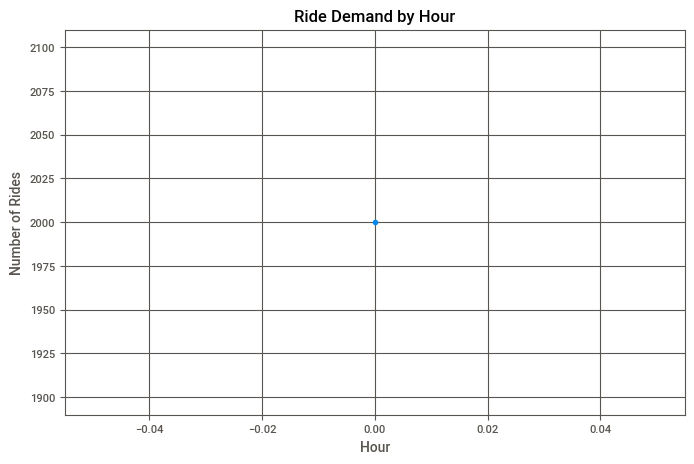

In [36]:
#Visualization 1 : Ride Demand by Hour
print(trips.columns)
print(trips.columns)
trips['ride_date'] = pd.to_datetime(trips['ride_date'])
trips['hour'] = trips['ride_date'].dt.hour

ride_hour = trips['hour'].value_counts().sort_index()

plt.figure(figsize=(8,5))
plt.plot(ride_hour.index, ride_hour.values, marker='o')

plt.xlabel("Hour")
plt.ylabel("Number of Rides")
plt.title("Ride Demand by Hour")
plt.grid()
plt.show()

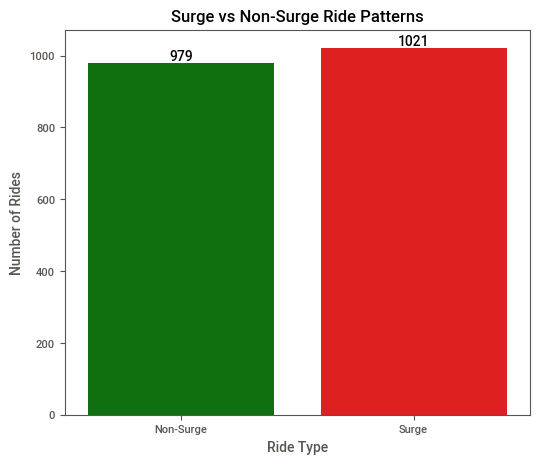

In [37]:
#Visualization 2 : Surge vs Non-Surge Ride Patterns

plt.figure(figsize=(6,5))

ax = sns.countplot(
    x='surge_flag',
    data=trips,
    hue='surge_flag',
    palette={0:'green', 1:'red'},
    legend=False
)

plt.xticks([0,1], ['Non-Surge', 'Surge'])
plt.xlabel("Ride Type")
plt.ylabel("Number of Rides")
plt.title("Surge vs Non-Surge Ride Patterns")

# Add count values on bars
for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom'
    )

plt.show()